In [6]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tf_keras import layers, models, callbacks


from qkeras import QActivation, QConv2D, QConv2DTranspose, QDense
from qkeras import quantized_bits, quantized_relu
from qkeras.utils import model_save_quantized_weights

In [ ]:
def build_tiny_autoencoder(input_shape=(64, 64, 1)):
    # encoder section
    input_img = layers.Input(shape=input_shape)
    
    # 2 layers of convolution, keep kernels and filters small to reduce hw resources
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Down to 32x32
    
    x = layers.Conv2D(4, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Down to 16x16
    
    # Spectrogram latent space - where the NN represents the essence of a sample
    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = layers.Flatten()(x)
    latent_space = layers.Dense(32, name="latent_space")(x) 
    
    # decoder section - reconstruct the orignal spectrogram using the latent representation
    dense_shape = np.prod([s for s in shape_before_flattening])
    x = layers.Dense(dense_shape)(latent_space)
    x = layers.Reshape(shape_before_flattening)(x)
    
    x = layers.Conv2DTranspose(4, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2DTranspose(8, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    return models.Model(input_img, decoded)

autoencoder = build_tiny_autoencoder()
autoencoder.compile(optimizer='adam', loss='mae')

In [15]:
def spectrogram_to_tensor(spectrogram, window_size=64, step_size=32):
    # We want to create windows of 64x64
    n_mels, steps = spectrogram.shape
    windows = []
    for start in range(0, steps - window_size + 1, step_size):
            window = spectrogram[:, start : start + window_size]
            windows.append(window)
    
    X = np.array(windows)
    X = np.expand_dims(X, axis=-1)
    return X

def create_dataset(data_dir, file = None, window_size=64, step_size=32):
    all_windows = []
    if file is not None:
        files = [file]
    else:
        files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
    
    for f in files:
        spec = np.load(os.path.join(data_dir, f))
        
        all_windows.append(spectrogram_to_tensor(spec, window_size, step_size))

    X = np.concatenate(all_windows, axis=0)
    np.random.shuffle(X)
    return X

X_train = create_dataset('../data/spectrogram/normal/')

# 2. Split for validation (keep 20% back to check for overfitting)
split = int(0.8 * len(X_train))
train_data = X_train[:split]
val_data = X_train[split:]

print(f"Total training windows: {len(train_data)}")

Total training windows: 6835


In [10]:
# 3. Train
# In autoencoders, x and y are the same!
history = autoencoder.fit(
    train_data, train_data,
    epochs=50,
    batch_size=32,
    validation_data=(val_data, val_data),
    shuffle=True
)

2026-04-07 10:08:37.777897: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 111984640 exceeds 10% of free system memory.
2026-04-07 10:08:38.478086: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 111984640 exceeds 10% of free system memory.
2026-04-07 10:08:39.279074: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 111984640 exceeds 10% of free system memory.
2026-04-07 10:08:39.478519: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 111984640 exceeds 10% of free system memory.


Epoch 1/50


2026-04-07 10:08:54.456596: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-04-07 10:08:58.775470: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ad432b59740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-07 10:08:58.775533: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-04-07 10:08:58.814393: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775549338.979588   80880 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


214/214 [==============================] - ETA: 0s - loss: 0.0798

2026-04-07 10:09:05.096511: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28000256 exceeds 10% of free system memory.


214/214 [==============================] - 26s 26ms/step - loss: 0.0798 - val_loss: 0.0490
Epoch 2/50
214/214 [==============================] - 2s 11ms/step - loss: 0.0469 - val_loss: 0.0457
Epoch 3/50
214/214 [==============================] - 2s 11ms/step - loss: 0.0449 - val_loss: 0.0443
Epoch 4/50
214/214 [==============================] - 2s 12ms/step - loss: 0.0439 - val_loss: 0.0437
Epoch 5/50
214/214 [==============================] - 2s 11ms/step - loss: 0.0431 - val_loss: 0.0429
Epoch 6/50
214/214 [==============================] - 2s 11ms/step - loss: 0.0424 - val_loss: 0.0423
Epoch 7/50
214/214 [==============================] - 2s 11ms/step - loss: 0.0420 - val_loss: 0.0421
Epoch 8/50
214/214 [==============================] - 2s 11ms/step - loss: 0.0415 - val_loss: 0.0418
Epoch 9/50
214/214 [==============================] - 2s 11ms/step - loss: 0.0413 - val_loss: 0.0414
Epoch 10/50
214/214 [==============================] - 2s 12ms/step - loss: 0.0410 - val_loss: 0.0411

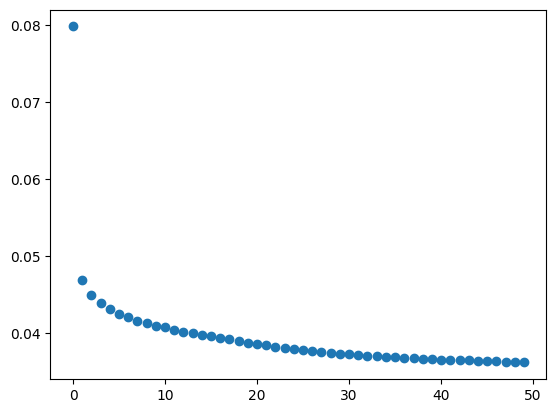

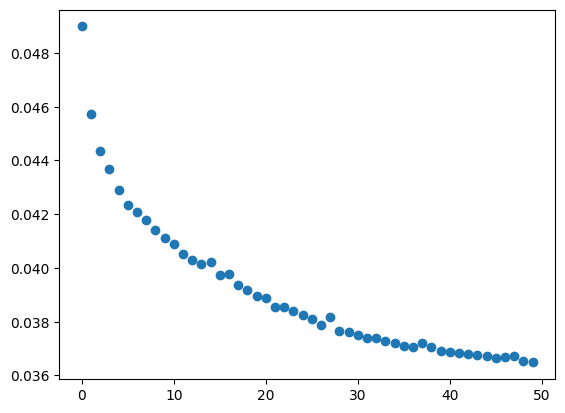

In [11]:
plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.figure()
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')

In [ ]:
autoencoder.save('auto_encoder.keras')

In [16]:
%run audio.ipynb

def detect_anomalies(file_path, model, threshold=0.05):
    spec = generate_fpga_style_spectrogram(file_path) # (64, 313)
    
    windows = spectrogram_to_tensor(spec) 
    print(f"Windows Shape: {windows.shape}")
    
    reconstructed = model.predict(windows)
    
    errors = np.mean(np.abs(windows - reconstructed), axis=(1, 2, 3))
    
    anomalous_indices = np.where(errors > threshold)[0]
    
    return errors, anomalous_indices

In [ ]:
detect_anomalies('../-6_dB_slider/slider/id_00/normal/00000011.wav', autoencoder)

Windows Shape: (8, 64, 64, 1)
1/1 [==============================] - 0s 68ms/step


(array([0.03640854, 0.03407212, 0.03326018, 0.03265746, 0.03242724,
        0.03324255, 0.03347991, 0.03245583], dtype=float32),
 array([], dtype=int64))

: 